# Phase 1B Provider Profiling Review

Phase 1B profiles enabled primary AMC/provider websites from `configs/amc_sources.yaml` and determines the best extraction strategy. It does **not** download all documents, parse documents, or load PostgreSQL.

This notebook prefers existing provider-profile and debug artifacts. Live profiling and optional exports are disabled by default.

## 1. Imports and paths

In [1]:
from pathlib import Path
import json
import subprocess
import sys
from urllib.parse import urlparse

import pandas as pd
from IPython.display import Image, display


def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'mutual_fund_ingestion' / '__init__.py').is_file():
            return candidate
    raise RuntimeError('Run this notebook from inside the Financial Analytics Work repository.')


def available_columns(frame, requested):
    return [column for column in requested if column in frame.columns]


def show_columns(frame, requested, *, empty_message='No matching records.'):
    columns = available_columns(frame, requested)
    if frame.empty:
        print(empty_message)
        return frame.reindex(columns=columns)
    return frame.loc[:, columns]


def read_jsonl(path):
    if not path.exists():
        print(f'Missing optional artifact: {path}')
        return []
    records = []
    for line_number, line in enumerate(path.read_text(encoding='utf-8').splitlines(), 1):
        if line.strip():
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                print(f'Skipping invalid JSONL record {path}:{line_number}: {exc}')
    return records

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ROOT

from mutual_fund_ingestion.artifacts import ArtifactPaths, load_latest_profiles
from mutual_fund_ingestion.models import ProviderProfile
from mutual_fund_ingestion.registry import load_sources
from mutual_fund_ingestion.reports import calculate_metrics

REGISTRY_PATH = ROOT / 'configs/amc_sources.yaml'
PROFILE_PATHS = ArtifactPaths.from_roots(
    ROOT / 'data/raw/mutual_funds/provider_profiles',
    ROOT / 'data/reports/mutual_funds',
    ROOT / 'data/debug/mutual_funds/provider_profiles',
)
UNRESOLVED_EXPORT = ROOT / 'data/reports/mutual_funds/phase_1_5_unresolved_candidates.csv'
PATHS = {
    'registry_config': REGISTRY_PATH,
    'profile_history': PROFILE_PATHS.history,
    'latest_profiles': PROFILE_PATHS.latest,
    'profile_summary_csv': PROFILE_PATHS.summary_csv,
    'profile_report_html': PROFILE_PATHS.report_html,
    'debug_root': PROFILE_PATHS.debug_root,
}
pd.DataFrame([{'artifact': name, 'path': str(path), 'exists': path.exists()} for name, path in PATHS.items()])

,artifact,path,exists
0,registry_config,/Users/vedaangchopra/all_data/complete_technic...,True
1,profile_history,/Users/vedaangchopra/all_data/complete_technic...,True
2,latest_profiles,/Users/vedaangchopra/all_data/complete_technic...,True
3,profile_summary_csv,/Users/vedaangchopra/all_data/complete_technic...,False
4,profile_report_html,/Users/vedaangchopra/all_data/complete_technic...,False
5,debug_root,/Users/vedaangchopra/all_data/complete_technic...,True


## 2. Load source registry input

In [2]:
if REGISTRY_PATH.exists():
    provider_sources = load_sources(REGISTRY_PATH)
    provider_source_df = pd.DataFrame([source.__dict__ for source in provider_sources])
else:
    print(f'Missing required registry: {REGISTRY_PATH}')
    provider_sources = []
    provider_source_df = pd.DataFrame()
show_columns(provider_source_df, ['amc_name', 'seed_url', 'source_role', 'source_type', 'enabled', 'expected_document_types', 'discovered_from'])

,amc_name,seed_url,source_role,source_type,enabled,expected_document_types,discovered_from
0,360 ONE Mutual Fund,https://www.360.one/asset/mutual-funds/downloads/,primary_provider,provider_download_page,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
1,Abakkus Mutual Fund,https://www.abakkusmf.com/statutory-disclosure...,primary_provider,provider_homepage,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
2,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/form...,primary_provider,provider_disclosure_page,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
3,AlphaGrep Mutual Fund,https://alphagrepmf.com/,primary_provider,provider_homepage,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
4,Angel One Mutual Fund,https://www.angelonemf.com/,primary_provider,provider_homepage,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
5,ASK Mutual Fund,https://www.askfinancials.com/,primary_provider,provider_homepage,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
6,Axis Mutual Fund,https://www.axismf.com/statutory-disclosures,primary_provider,provider_disclosure_page,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
7,Bajaj Finserv Mutual Fund,https://www.bajajamc.com/downloads?statutory-d...,primary_provider,provider_download_page,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
8,Bandhan Mutual Fund,https://bandhanmutual.com/downloads/disclosures,primary_provider,provider_download_page,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"
9,Bank of India Mutual Fund,https://www.boimf.in/regulatory-reports,primary_provider,provider_download_page,True,"(factsheet, portfolio_disclosure)","(manual_curated, existing_config)"


## 3. Optional small provider profiling run

In [13]:
RUN_LIVE_SAMPLE = True
SAMPLE_LIMIT = -1

if RUN_LIVE_SAMPLE:
    command = [sys.executable, '-m', 'mutual_fund_ingestion', 'profile-providers', '--limit', str(SAMPLE_LIMIT), '--dry-run']
    result = subprocess.run(command, cwd=ROOT, text=True, capture_output=True, check=False)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
else:
    print('Live Phase 1B sample disabled. Set RUN_LIVE_SAMPLE = True to run profile-providers --dry-run.')

{
  "metrics": {
    "total_amcs": 52,
    "profiled_successfully": 41,
    "partial_success": 1,
    "failed": 5,
    "manual_review_required": 5,
    "static_html_count": 33,
    "network_api_count": 1,
    "playwright_count": 8,
    "vlm_required_count": 4,
    "manual_review_count": 3,
    "failed_blocked_count": 3,
    "total_static_links_found": 15418,
    "total_download_links_found": 9552,
    "total_candidate_document_links_found": 10321,
    "file_type_counts": {
      "csv": 1,
      "pdf": 33,
      "xls": 12,
      "xlsx": 22,
      "zip": 2
    }
  },
  "profiles": [
    {
      "run_id": "20260607_191800_notebook",
      "created_at": "2026-06-07T19:18:00.678725Z",
      "amc_name": "360 ONE Mutual Fund",
      "seed_url": "https://www.360one.com/asset-management/mutual-fund/downloads/",
      "status": "manual_review_required",
      "detected_strategy": "manual_review",
      "requires_javascript": null,
      "static_links_found": 0,
      "download_links_found": 0,
 

## 4. Load provider profiles

In [14]:
if PROFILE_PATHS.latest.exists():
    latest_profiles = load_latest_profiles(PROFILE_PATHS.latest)
    profiles = list(latest_profiles.values())
    profile_source = PROFILE_PATHS.latest
elif PROFILE_PATHS.history.exists():
    history_records = read_jsonl(PROFILE_PATHS.history)
    latest_by_amc = {}
    for record in history_records:
        try:
            profile = ProviderProfile.from_dict(record)
            latest_by_amc[profile.amc_name] = profile
        except (TypeError, ValueError) as exc:
            print(f'Skipping invalid provider profile: {exc}')
    profiles = list(latest_by_amc.values())
    profile_source = PROFILE_PATHS.history
else:
    print('No provider profile artifact found.')
    profiles = []
    profile_source = None

profile_df = pd.DataFrame([profile.to_dict() for profile in profiles])
print(f'Loaded {len(profiles)} profiles from {profile_source}')
show_columns(profile_df, [
    'amc_name', 'seed_url', 'status', 'detected_strategy', 'strategy_confidence',
    'requires_javascript', 'static_links_found', 'rendered_links_found', 'download_links_found',
    'candidate_document_links_found', 'file_types_found', 'failure_reason'
])

Loaded 5 profiles from /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Financial Analytics Work/data/raw/mutual_funds/provider_profiles/provider_profiles.latest.json


,amc_name,seed_url,status,detected_strategy,strategy_confidence,requires_javascript,static_links_found,rendered_links_found,download_links_found,candidate_document_links_found,file_types_found,failure_reason
0,360 ONE Mutual Fund,https://www.360one.com/asset-management/mutual...,manual_review_required,manual_review,unknown,None,0,0,0,0,(),NaN
1,Abakkus Mutual Fund,https://abakkusmf.com/,failed,manual_review,unknown,None,0,0,0,0,(),static_html: HTTPSConnectionPool(host='www.aba...
2,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/form...,success,static_html,unknown,False,509,0,3,37,"(pdf,)",NaN
3,HDFC Mutual Fund,https://www.hdfcfund.com/statutory-disclosure/...,failed,manual_review,unknown,None,0,0,0,0,(),static_html: 404 Client Error: Not Found for u...
4,PPFAS Mutual Fund,https://amc.ppfas.com/downloads/,success,static_html,unknown,False,74,0,2,13,"(pdf,)",NaN


## 5. Strategy and status distribution

In [15]:
concrete_strategies = {'static_html', 'network_api', 'playwright'}
unresolved_strategies = {'manual_review', 'unknown', 'vlm_required', 'failed_blocked'}

if profile_df.empty:
    strategy_distribution = pd.DataFrame(columns=['detected_strategy', 'count'])
    status_distribution = pd.DataFrame(columns=['status', 'count'])
else:
    strategy_distribution = profile_df.get('detected_strategy', pd.Series(dtype=object)).fillna('unknown').value_counts().rename_axis('detected_strategy').reset_index(name='count')
    status_distribution = profile_df.get('status', pd.Series(dtype=object)).fillna('unknown').value_counts().rename_axis('status').reset_index(name='count')
display(strategy_distribution)
display(status_distribution)

metrics = calculate_metrics(profiles) if profiles else {}
pd.DataFrame([{'metric': key, 'value': value} for key, value in metrics.items()])

,detected_strategy,count
0,manual_review,3
1,static_html,2


,status,count
0,failed,2
1,success,2
2,manual_review_required,1


,metric,value
0,total_amcs,5
1,profiled_successfully,2
2,partial_success,0
3,failed,2
4,manual_review_required,1
5,static_html_count,2
6,network_api_count,0
7,playwright_count,0
8,vlm_required_count,0
9,manual_review_count,3


## 6. Candidate link inspection

In [16]:
candidate_rows = []
for profile in profiles:
    for candidate in profile.candidate_links:
        candidate_rows.append({
            'amc_name': profile.amc_name,
            'candidate_link': candidate.url,
            'link_text': candidate.text,
            'file_type': candidate.file_type,
            'document_type_hint': candidate.document_type_hint,
            'source_page': candidate.source_page_url,
            'discovery_method': candidate.discovery_method,
        })
candidate_link_df = pd.DataFrame(candidate_rows)
show_columns(candidate_link_df, ['amc_name', 'candidate_link', 'link_text', 'file_type', 'document_type_hint', 'source_page', 'discovery_method'])

,amc_name,candidate_link,link_text,file_type,document_type_hint,source_page,discovery_method
0,Aditya Birla Sun Life Mutual Fund,https://portfoliomanagementservices.adityabirl...,Portfolio Management Services,NaN,portfolio_disclosure,https://mutualfund.adityabirlacapital.com/form...,static_html
1,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/port...,Register for e-OTM,NaN,ter,https://mutualfund.adityabirlacapital.com/form...,static_html
2,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/-/me...,Tax Reckoner,pdf,unknown,https://mutualfund.adityabirlacapital.com/form...,static_html
3,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/form...,Monthly Factsheet,NaN,factsheet,https://mutualfund.adityabirlacapital.com/form...,static_html
4,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/-/me...,Demat to Re-mat Process,pdf,ter,https://mutualfund.adityabirlacapital.com/form...,static_html
5,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/form...,Forms,NaN,form,https://mutualfund.adityabirlacapital.com/form...,static_html
6,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/form...,Total Expense Ratio,NaN,ter,https://mutualfund.adityabirlacapital.com/form...,static_html
7,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/form...,Information Ratio (IR),NaN,form,https://mutualfund.adityabirlacapital.com/form...,static_html
8,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/form...,Rationale For Valuation,NaN,form,https://mutualfund.adityabirlacapital.com/form...,static_html
9,Aditya Birla Sun Life Mutual Fund,https://mutualfund.adityabirlacapital.com/form...,Schemes’ Risk-o-Meter,NaN,ter,https://mutualfund.adityabirlacapital.com/form...,static_html


## 7. Debug artifact inspection

,amc_name,static_html_snapshot,rendered_html_snapshot,screenshot,network_log,accessibility_snapshot,error_json
0,360 ONE Mutual Fund,/Users/vedaangchopra/all_data/complete_technic...,/Users/vedaangchopra/all_data/complete_technic...,/Users/vedaangchopra/all_data/complete_technic...,/Users/vedaangchopra/all_data/complete_technic...,/Users/vedaangchopra/all_data/complete_technic...,/Users/vedaangchopra/all_data/complete_technic...
1,Abakkus Mutual Fund,NaN,NaN,/Users/vedaangchopra/all_data/complete_technic...,/Users/vedaangchopra/all_data/complete_technic...,NaN,/Users/vedaangchopra/all_data/complete_technic...
2,Aditya Birla Sun Life Mutual Fund,/Users/vedaangchopra/all_data/complete_technic...,NaN,NaN,NaN,NaN,NaN
3,HDFC Mutual Fund,NaN,NaN,NaN,NaN,NaN,/Users/vedaangchopra/all_data/complete_technic...
4,PPFAS Mutual Fund,/Users/vedaangchopra/all_data/complete_technic...,NaN,NaN,NaN,NaN,NaN


Displaying: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Financial Analytics Work/data/debug/mutual_funds/provider_profiles/360_one_mutual_fund/screenshot.png


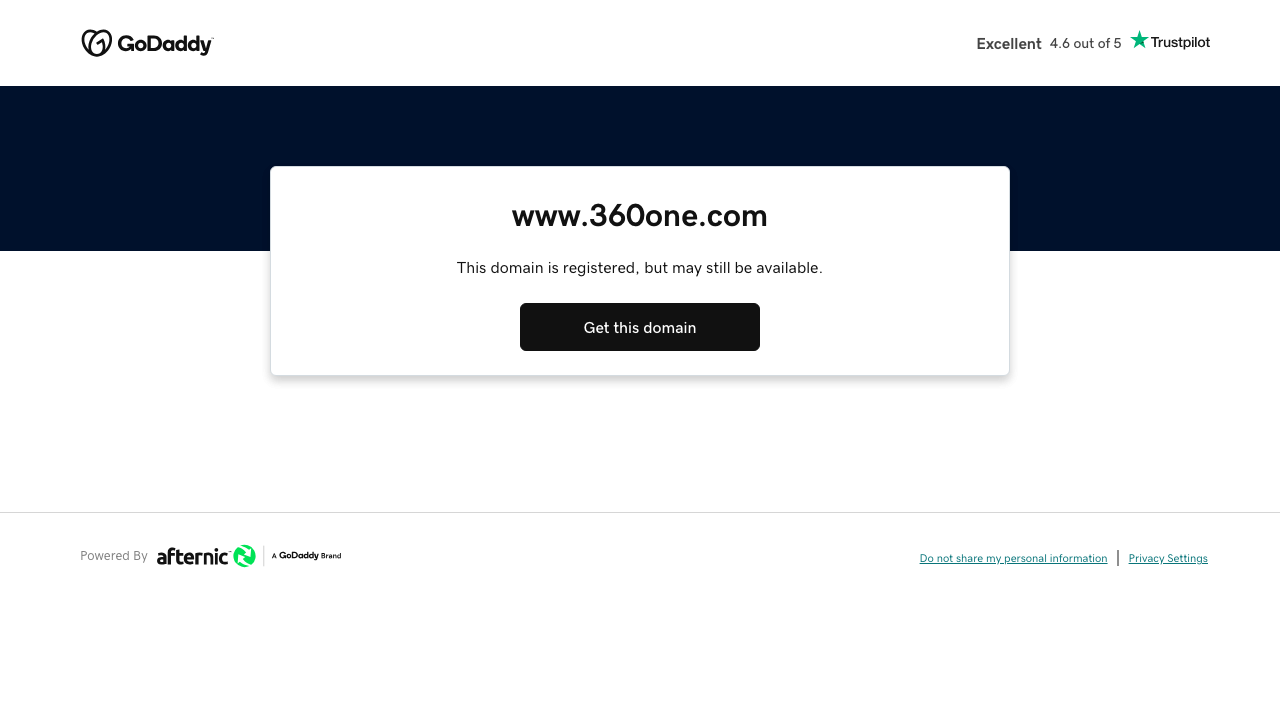

Displaying: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Financial Analytics Work/data/debug/mutual_funds/provider_profiles/abakkus_mutual_fund/screenshot.png


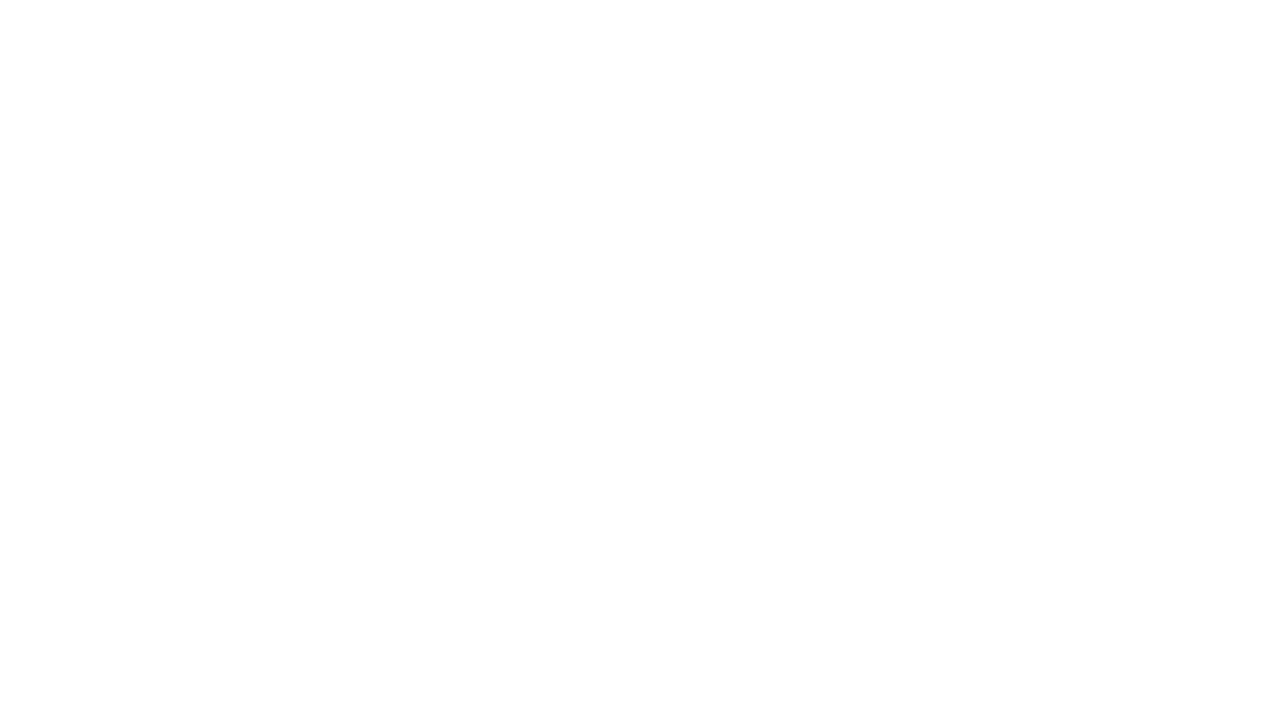

In [17]:
artifact_rows = []
for profile in profiles:
    artifacts = profile.debug_artifacts or {}
    artifact_rows.append({
        'amc_name': profile.amc_name,
        'static_html_snapshot': artifacts.get('static_html'),
        'rendered_html_snapshot': artifacts.get('rendered_html'),
        'screenshot': artifacts.get('screenshot'),
        'network_log': artifacts.get('network_log'),
        'accessibility_snapshot': artifacts.get('accessibility_snapshot'),
        'error_json': artifacts.get('profiler_error'),
    })
debug_df = pd.DataFrame(artifact_rows)
display(show_columns(debug_df, ['amc_name', 'static_html_snapshot', 'rendered_html_snapshot', 'screenshot', 'network_log', 'accessibility_snapshot', 'error_json']))

screenshot_paths = []
if 'screenshot' in debug_df:
    screenshot_paths = [Path(value) for value in debug_df['screenshot'].dropna() if Path(value).exists()][:2]
if screenshot_paths:
    for screenshot in screenshot_paths:
        print(f'Displaying: {screenshot}')
        display(Image(filename=str(screenshot)))
else:
    print('No saved screenshots are available.')

## 8. Failure and manual-review inspection

In [18]:
if profile_df.empty:
    unresolved_df = profile_df
else:
    strategy = profile_df.get('detected_strategy', pd.Series(index=profile_df.index, dtype=object)).fillna('unknown')
    status = profile_df.get('status', pd.Series(index=profile_df.index, dtype=object)).fillna('unknown')
    unresolved_mask = strategy.isin(unresolved_strategies) | status.isin({'failed', 'partial_success', 'manual_review_required'})
    unresolved_df = profile_df[unresolved_mask].copy()
    unresolved_df['candidate_links_count'] = unresolved_df.get('candidate_links', pd.Series([[] for _ in unresolved_df.index], index=unresolved_df.index)).map(lambda value: len(value or []))
show_columns(unresolved_df, ['amc_name', 'seed_url', 'status', 'detected_strategy', 'failure_reason', 'debug_artifacts', 'candidate_links_count'])

,amc_name,seed_url,status,detected_strategy,failure_reason,debug_artifacts,candidate_links_count
0,360 ONE Mutual Fund,https://www.360one.com/asset-management/mutual...,manual_review_required,manual_review,NaN,{'accessibility_snapshot': '/Users/vedaangchop...,0
1,Abakkus Mutual Fund,https://abakkusmf.com/,failed,manual_review,static_html: HTTPSConnectionPool(host='www.aba...,{'network_log': '/Users/vedaangchopra/all_data...,0
3,HDFC Mutual Fund,https://www.hdfcfund.com/statutory-disclosure/...,failed,manual_review,static_html: 404 Client Error: Not Found for u...,{'profiler_error': '/Users/vedaangchopra/all_d...,0


## 9. Optional Phase 1.5 candidate export

In [19]:
EXPORT_UNRESOLVED_CSV = True

if EXPORT_UNRESOLVED_CSV:
    UNRESOLVED_EXPORT.parent.mkdir(parents=True, exist_ok=True)
    show_columns(unresolved_df, ['amc_name', 'seed_url', 'status', 'detected_strategy', 'failure_reason', 'candidate_links_count']).to_csv(UNRESOLVED_EXPORT, index=False)
    print(f'Wrote unresolved candidate export: {UNRESOLVED_EXPORT}')
else:
    print(f'Export disabled. Set EXPORT_UNRESOLVED_CSV = True to write {UNRESOLVED_EXPORT}.')

Wrote unresolved candidate export: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Financial Analytics Work/data/reports/mutual_funds/phase_1_5_unresolved_candidates.csv


## 10. Output artifacts

In [20]:
artifact_path_df = pd.DataFrame([{'artifact': name, 'path': str(path), 'exists': path.exists()} for name, path in PATHS.items()])
display(artifact_path_df)
if PROFILE_PATHS.report_html.exists():
    print(f'Provider profile report: {PROFILE_PATHS.report_html}')

,artifact,path,exists
0,registry_config,/Users/vedaangchopra/all_data/complete_technic...,True
1,profile_history,/Users/vedaangchopra/all_data/complete_technic...,True
2,latest_profiles,/Users/vedaangchopra/all_data/complete_technic...,True
3,profile_summary_csv,/Users/vedaangchopra/all_data/complete_technic...,False
4,profile_report_html,/Users/vedaangchopra/all_data/complete_technic...,False
5,debug_root,/Users/vedaangchopra/all_data/complete_technic...,True


## 11. Readiness summary for Phase 1.5 and Phase 2

In [21]:
if profile_df.empty:
    readiness = {'total_profiled_providers': 0, 'recommended_next_step': 'Run a bounded Phase 1B profiling sample.'}
else:
    strategy = profile_df.get('detected_strategy', pd.Series(index=profile_df.index, dtype=object)).fillna('unknown')
    ready_count = int(strategy.isin(concrete_strategies).sum())
    unresolved_count = int(strategy.isin(unresolved_strategies).sum())
    readiness = {
        'total_profiled_providers': len(profile_df),
        'ready_providers_with_concrete_strategy': ready_count,
        'static_html_count': int(strategy.eq('static_html').sum()),
        'network_api_count': int(strategy.eq('network_api').sum()),
        'playwright_count': int(strategy.eq('playwright').sum()),
        'vlm_required_count': int(strategy.eq('vlm_required').sum()),
        'manual_review_or_unknown_count': int(strategy.isin({'manual_review', 'unknown'}).sum()),
        'failed_blocked_count': int(strategy.eq('failed_blocked').sum()),
        'recommended_next_step': (
            'Begin Phase 2 on the ready subset and route unresolved providers through Phase 1.5.'
            if ready_count > 0 else
            'Resolve provider strategies in Phase 1.5 before Phase 2.'
        ),
    }
readiness

{'total_profiled_providers': 5,
 'ready_providers_with_concrete_strategy': 2,
 'static_html_count': 2,
 'network_api_count': 0,
 'playwright_count': 0,
 'vlm_required_count': 0,
 'manual_review_or_unknown_count': 3,
 'failed_blocked_count': 0,
 'recommended_next_step': 'Begin Phase 2 on the ready subset and route unresolved providers through Phase 1.5.'}